In [1]:
#importing necessary packages
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

**Task 1**

In [2]:
#Loading Image.
im1=cv.imread(filename="D:\EN3160 - Image Procesing and Machine Vision Codes/Assignments/images/q1.jpeg",flags=cv.IMREAD_GRAYSCALE)
assert im1 is not None

In [3]:
#Function to Create Intensity Transformation Function based on given break points
def Intensity_Transform(c):
    parts = []
    for i in range(len(c) - 1):
        x1, y1 = c[i]
        x2, y2 = c[i + 1]
        # Ignore vertical sections
        if x1 == x2:
            continue
        # Values for x1, x1+1, ..., x2-1
        part = np.linspace(y1, y2, x2 - x1 + 1)[:-1]
        parts.append(part)
    # Add output value corresponding to x = 255
    parts.append(np.array([c[-1, 1]]))
    return np.concatenate(parts).astype('uint8')

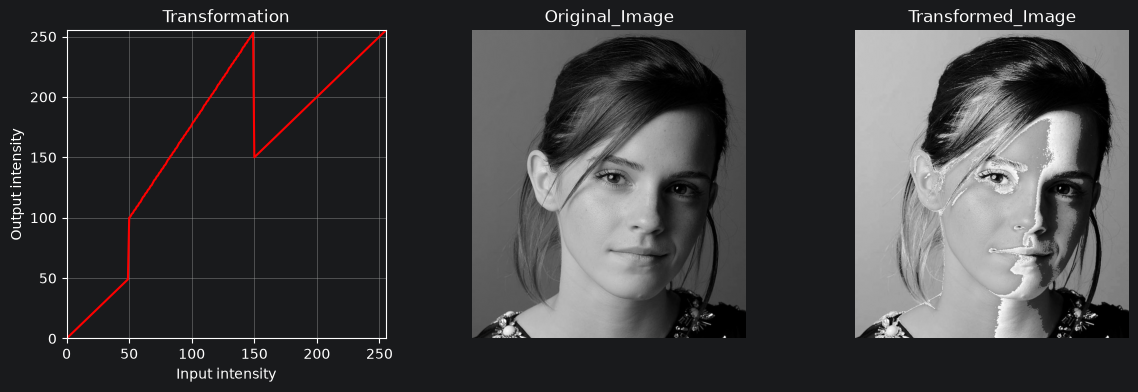

In [4]:
#Defining Intensity Transformation Function (Given Graph)
c = np.array([(0,0),(50,50), (50,100), (150,255), (150,150),(255,255)])
Transformation = Intensity_Transform(c)
Transformed_im = cv.LUT(im1, Transformation)

#Plotting Transformation Function and Original and Transformed Images
fig,ax = plt.subplots(nrows=1,ncols=3, figsize=(14,4))
ax[0].plot(Transformation, color='red')
ax[0].set_xlim(0, 255)
ax[0].set_ylim(0, 255)
ax[0].set_title('Transformation')
ax[0].set_xlabel('Input intensity')
ax[0].set_ylabel('Output intensity')
ax[0].grid()
ax[1].imshow(im1,cmap='gray',vmin=0,vmax=255)
ax[1].set_title('Original_Image')
ax[1].axis('off')
ax[2].imshow(Transformed_im,cmap='gray',vmin=0,vmax=255)
ax[2].set_title('Transformed_Image')
ax[2].axis('off')
plt.show()

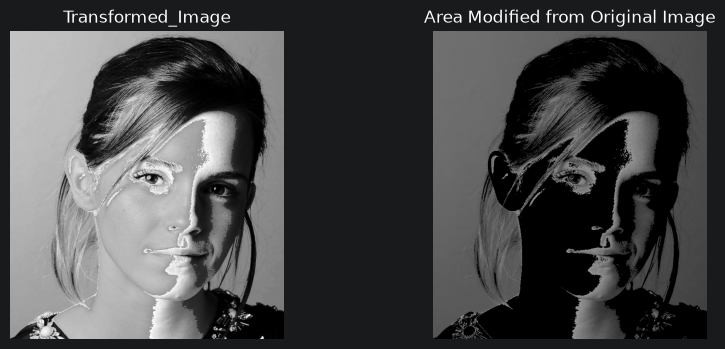

In [5]:
#Verifying Transformation By comparing transformed image with area modified from original image
#Since only intensities between 50 and 150 are modified, we can create a mask to extract that area from the original image and compare it with the transformed image.
c1=np.array([(0,0),(50,0), (50,50), (150,150), (150,0),(255,0)])
Transformation1 = Intensity_Transform(c1)
Transformed_im1 = cv.LUT(im1, Transformation1)

#Plotting Transformed Image and Area Modified from Original Image
fig,ax = plt.subplots(nrows=1,ncols=2, figsize=(10,4))
ax[0].imshow(Transformed_im,cmap='gray',vmin=0,vmax=255)
ax[0].set_title('Transformed_Image')
ax[0].axis('off')
ax[1].imshow(Transformed_im1,cmap='gray',vmin=0,vmax=255)
ax[1].set_title('Area Modified from Original Image')
ax[1].axis('off')
plt.show()

**Task 2**

*(a) Accentuating White Matter in Brain MRI Image*

In [6]:
#Loading Brain MRI Image.
im2=cv.imread(filename="D:\EN3160 - Image Procesing and Machine Vision Codes/Assignments/images/q2.jpeg",flags=cv.IMREAD_GRAYSCALE)
assert im2 is not None

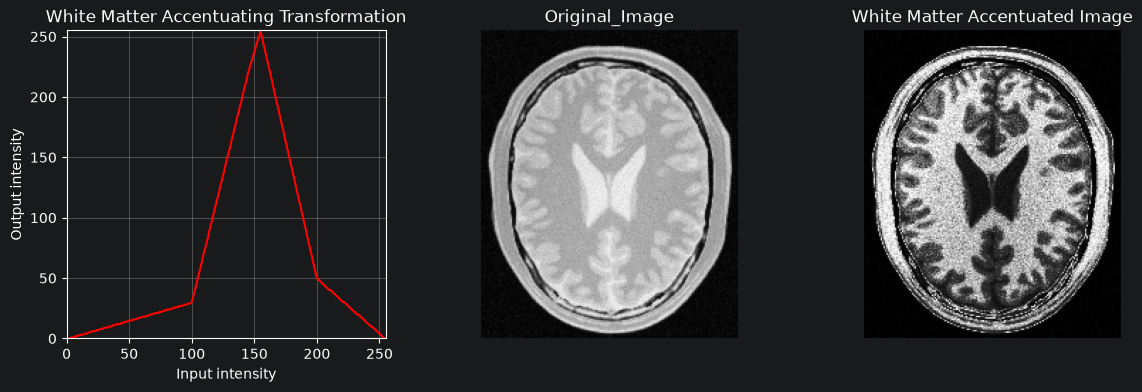

In [7]:
#Defining Break Points for Accentuating White Matter in Brain MRI Image
c_white = np.array([(0,0), (100,30), (145,220), (155,255),(200,50),(255,0)])
Transform_white = Intensity_Transform(c_white)
Transformed_im_white = cv.LUT(im2, Transform_white)

#Plotting Transformation Function and Original and Transformed Images
fig,ax = plt.subplots(nrows=1,ncols=3, figsize=(14,4))
ax[0].plot(Transform_white, color='red')
ax[0].set_xlim(0, 255)
ax[0].set_ylim(0, 255)
ax[0].set_title('White Matter Accentuating Transformation')
ax[0].set_xlabel('Input intensity')
ax[0].set_ylabel('Output intensity')
ax[0].grid()
ax[1].imshow(im2,cmap='gray',vmin=0,vmax=255)
ax[1].set_title('Original_Image')
ax[1].axis('off')
ax[2].imshow(Transformed_im_white,cmap='gray',vmin=0,vmax=255)
ax[2].set_title('White Matter Accentuated Image')
ax[2].axis('off')
plt.show()

*(b) Accentuating Gray Matter in Brain MRI Image*

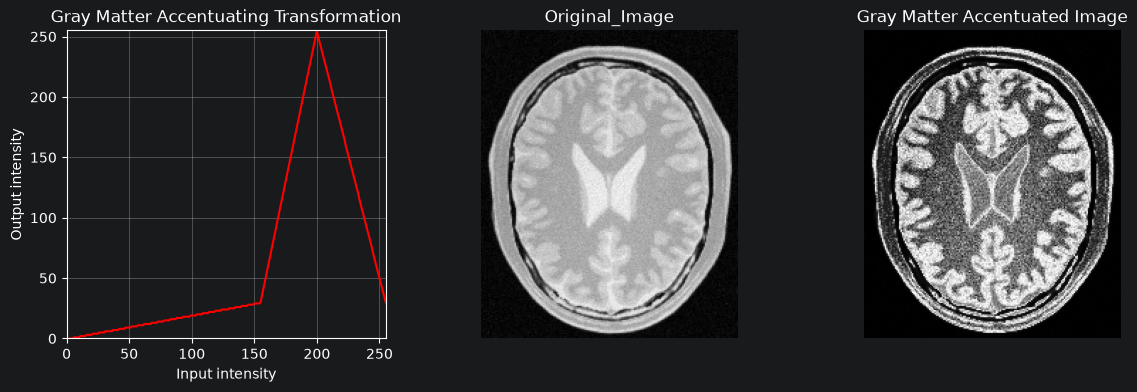

In [8]:
#Defining Break Points for Accentuating Gray Matter in Brain MRI Image
c_gray = np.array([(0,0),(155,30), (200,255), (255,30)])
Transform_gray = Intensity_Transform(c_gray)
Transformed_im_gray = cv.LUT(im2, Transform_gray)

#Plotting Transformation Function and Original and Transformed Images
fig,ax = plt.subplots(nrows=1,ncols=3, figsize=(14,4))
ax[0].plot(Transform_gray, color='red')
ax[0].set_xlim(0, 255)
ax[0].set_ylim(0, 255)
ax[0].set_title('Gray Matter Accentuating Transformation')
ax[0].set_xlabel('Input intensity')
ax[0].set_ylabel('Output intensity')
ax[0].grid()
ax[1].imshow(im2,cmap='gray',vmin=0,vmax=255)
ax[1].set_title('Original_Image')
ax[1].axis('off')
ax[2].imshow(Transformed_im_gray,cmap='gray',vmin=0,vmax=255)
ax[2].set_title('Gray Matter Accentuated Image')
ax[2].axis('off')
plt.show()

**Task 3**

*(a) Gamma Correction on Color Image For Gamma = 0.6*

In [9]:
#Loading Image.
im3 = cv.imread(filename="D:\EN3160 - Image Procesing and Machine Vision Codes/Assignments/images/q3.jpeg")
assert im3 is not None

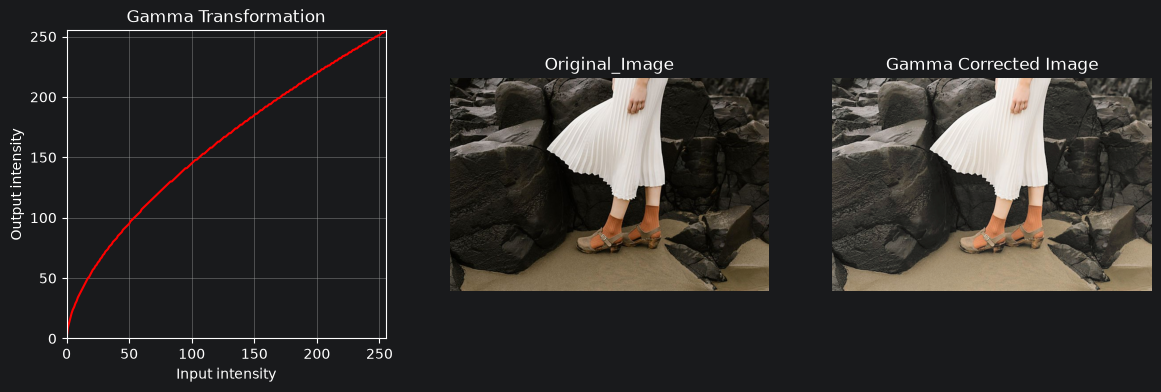

In [10]:
#Defining Gamma Value
gamma=0.6
#Converting Image to LAB Color Space
im3_lab = cv.cvtColor(im3, cv.COLOR_BGR2LAB)
#Extracting Luminance Channel
im3_l = im3_lab[:,:,0]
#Transformation Function for Gamma Correction
Gamma_Transformation = np.array([((i/255.0)**gamma)*255 for i in range(256)]).astype('uint8')
#Applying Gamma Correction to Luminance Channel
Transformed_im3 = cv.LUT(im3_l, Gamma_Transformation)
#Replacing Luminance Channel with Transformed Luminance Channel
im3_lab[:,:,0] = Transformed_im3
#Converting Image back to BGR Color Space
im3_final = cv.cvtColor(im3_lab, cv.COLOR_LAB2BGR)

#Plotting Transformation Function and Original and Transformed Images
fig,ax = plt.subplots(nrows=1,ncols=3, figsize=(14,4))
ax[0].plot(Gamma_Transformation, color='red')
ax[0].set_xlim(0, 255)
ax[0].set_ylim(0, 255)
ax[0].set_title('Gamma Transformation')
ax[0].set_xlabel('Input intensity')
ax[0].set_ylabel('Output intensity')
ax[0].grid()
ax[1].imshow(cv.cvtColor(im3, cv.COLOR_BGR2RGB))
ax[1].set_title('Original_Image')
ax[1].axis('off')
ax[2].imshow(cv.cvtColor(im3_final, cv.COLOR_BGR2RGB))
ax[2].set_title('Gamma Corrected Image')
ax[2].axis('off')
plt.show()


*(b) Plotting Histogram of Original and Gamma Corrected Images*

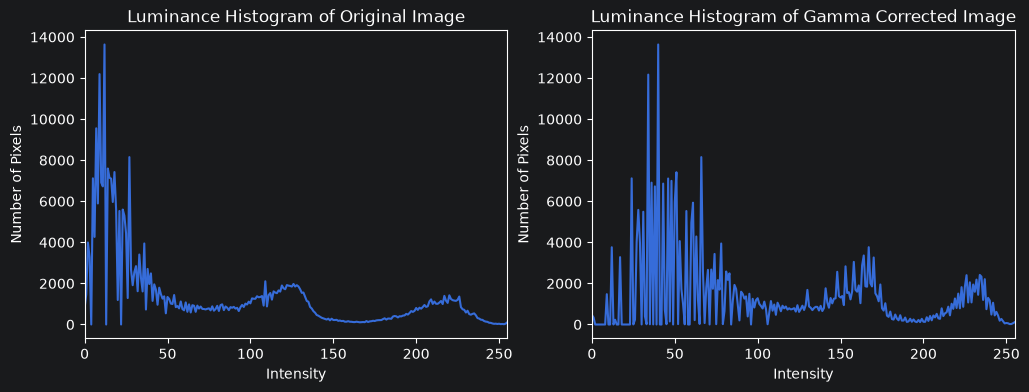

In [11]:
#Converting Original and Gamma Corrected Images to LAB Color Space To View Histograms of Luminance Channel
im3_= cv.cvtColor(im3, cv.COLOR_BGR2LAB)
im3_final_ = cv.cvtColor(im3_final, cv.COLOR_BGR2LAB)
#Calculating Histogram of Luminance Channel of Original and Gamma Corrected Images
original_histogram = cv.calcHist([im3_], [0], None, [256], [0, 256])
gamma_corrected_histogram = cv.calcHist([im3_final_], [0], None, [256], [0, 256])
#Plotting Histogram of Original and Gamma Corrected Images
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(original_histogram)
ax[0].set_title('Luminance Histogram of Original Image')
ax[0].set_xlabel('Intensity')
ax[0].set_ylabel('Number of Pixels')
ax[0].set_xlim([0,255])
ax[1].plot(gamma_corrected_histogram)
ax[1].set_title('Luminance Histogram of Gamma Corrected Image')
ax[1].set_xlabel('Intensity')
ax[1].set_ylabel('Number of Pixels')
ax[1].set_xlim([0,255])
plt.show()

**Task 4**

*(a) Loading and Splitting Image into HSV Planes*

In [12]:
#Loading Image
im4=cv.imread(filename="D:\EN3160 - Image Procesing and Machine Vision Codes/Assignments/images/q4.jpeg")
assert im4 is not None
#Converting BGR to HSV
im4_hsv=cv.cvtColor(im4,cv.COLOR_BGR2HSV)
#splitting into seperate H,S,V arrays
im4_hue=im4_hsv[:,:,0]
im4_sat=im4_hsv[:,:,1]
im4_val=im4_hsv[:,:,2]

*(b),(c) Applying Transformation to Saturation Plane and Adjusting value a(a=0.6) to get a visually Pleasing Output*

In [13]:
a=0.6 #Setting Value a
sigma=70
#Defining Transformation Function
q4_Transformation=np.array([min(i + a*128*np.exp(-((i-128)**2)/(2*sigma**2)),255)for i in range(256)]).astype('uint8')
#Applying Transformation to Saturation Plane
im4_sat_transformed=cv.LUT(im4_sat,q4_Transformation)

*(d) Recombining the Layers*

In [14]:
#Replacing Saturation Array in original image with transformed array
im4_hsv[:,:,1]=im4_sat_transformed #now im4_hsv contains Saturation Transformed Image

*(e) Plotting Transformation, Original Image and Transformed Image*

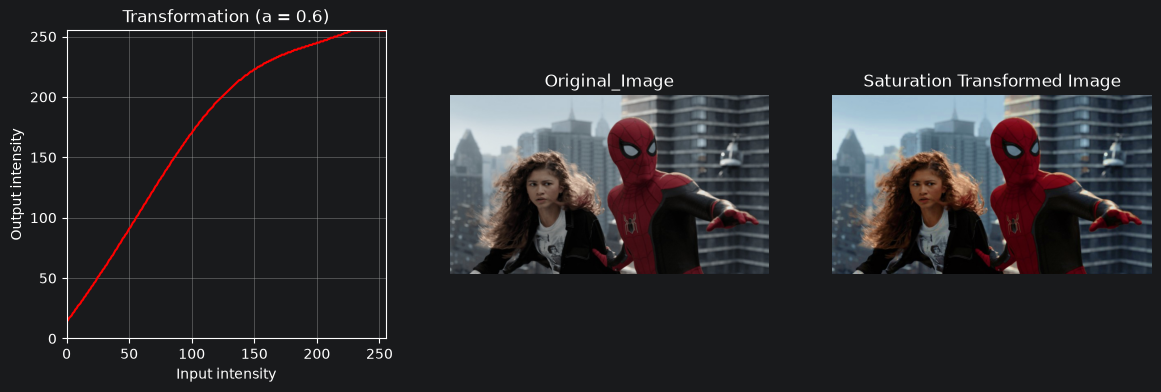

In [15]:
#Plotting Transformation Function and Original and Transformed Images
fig,ax = plt.subplots(nrows=1,ncols=3, figsize=(14,4))
ax[0].plot(q4_Transformation, color='red')
ax[0].set_xlim(0, 255)
ax[0].set_ylim(0, 255)
ax[0].set_title(f'Transformation (a = {a})')
ax[0].set_xlabel('Input intensity')
ax[0].set_ylabel('Output intensity')
ax[0].grid()
ax[1].imshow(cv.cvtColor(im4, cv.COLOR_BGR2RGB))
ax[1].set_title('Original_Image')
ax[1].axis('off')
ax[2].imshow(cv.cvtColor(im4_hsv, cv.COLOR_HSV2RGB))
ax[2].set_title('Saturation Transformed Image')
ax[2].axis('off')
plt.show()

**Task 5**

In [16]:
#Loading Image
im5=cv.imread(filename="D:\EN3160 - Image Procesing and Machine Vision Codes/Assignments/images/q5.tif", flags=cv.IMREAD_GRAYSCALE)
assert im5 is not None

(np.float64(-0.5), np.float64(499.5), np.float64(499.5), np.float64(-0.5))

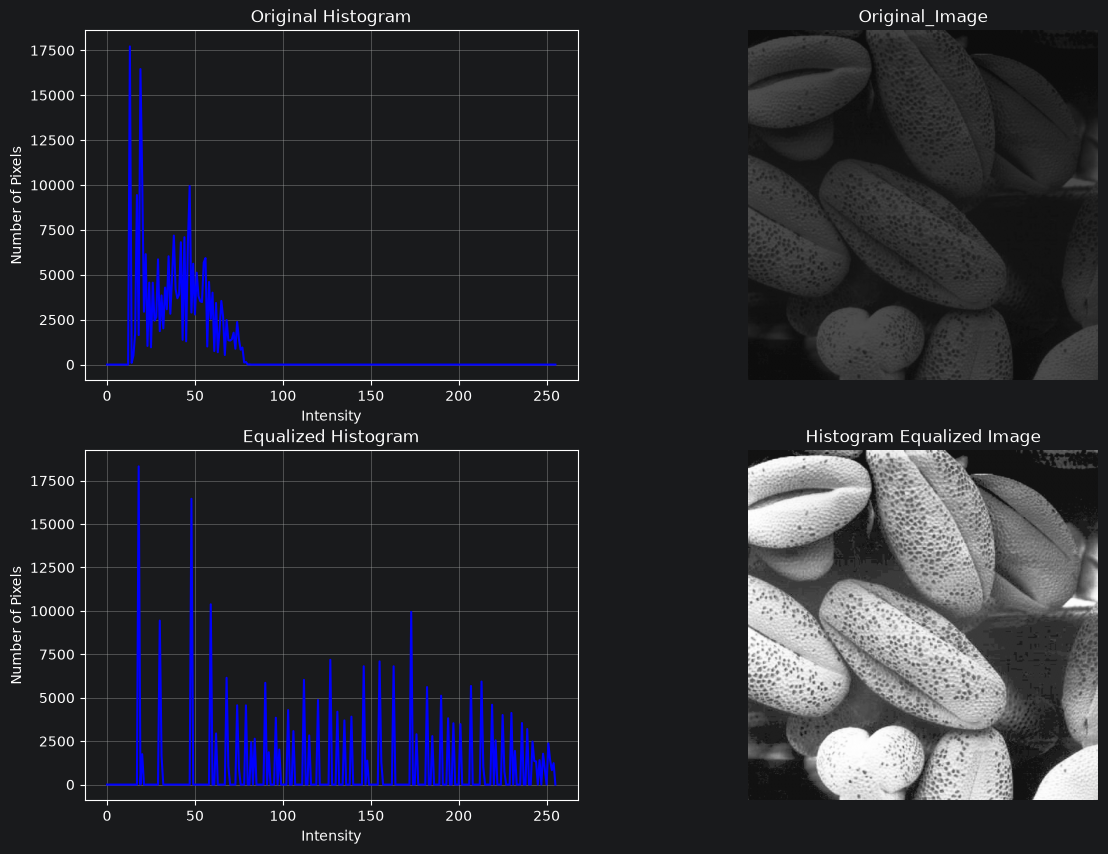

In [26]:
#For 8-bit Grayscale Image
L=256
M,N= im5.shape

#Creating Histogram and cdf for histogram equalization
hist = cv.calcHist([im5], [0], None, [256], [0,256])
cdf = hist.cumsum()

#Function for Histogram Equalization
Histogram_Eq_Transform = np.array([(L-1)/(M*N)*cdf[i] for i in range(256)]).astype('uint8')

#Applying Histogram Equalization
im5_equalized = cv.LUT(im5, Histogram_Eq_Transform)

#Creating Histogram of Histogram Equalized Image
hist_equalized = cv.calcHist([im5_equalized], [0], None, [256], [0,256])

#Plotting Original and Transformed Images With Original and Equalized Histograms
fig,ax = plt.subplots(nrows=2,ncols=2, figsize=(14,10))
ax[0][0].plot(hist, color='blue')
ax[0][0].set_title('Original Histogram')
ax[0][0].set_xlabel('Intensity')
ax[0][0].set_ylabel('Number of Pixels')
ax[0][0].grid()
ax[0][1].imshow(im5,cmap='gray',vmin=0,vmax=255)
ax[0][1].set_title('Original_Image')
ax[0][1].axis('off')
ax[1][0].plot(hist_equalized, color='blue')
ax[1][0].set_title('Equalized Histogram')
ax[1][0].set_xlabel('Intensity')
ax[1][0].set_ylabel('Number of Pixels')
ax[1][0].grid()
ax[1][1].imshow(im5_equalized,cmap='gray',vmin=0,vmax=255)
ax[1][1].set_title('Histogram Equalized Image')
ax[1][1].axis('off')


**Task 6**